   LOAN APPROVAL — RANDOM FOREST CLASSIFIER PIPELINE


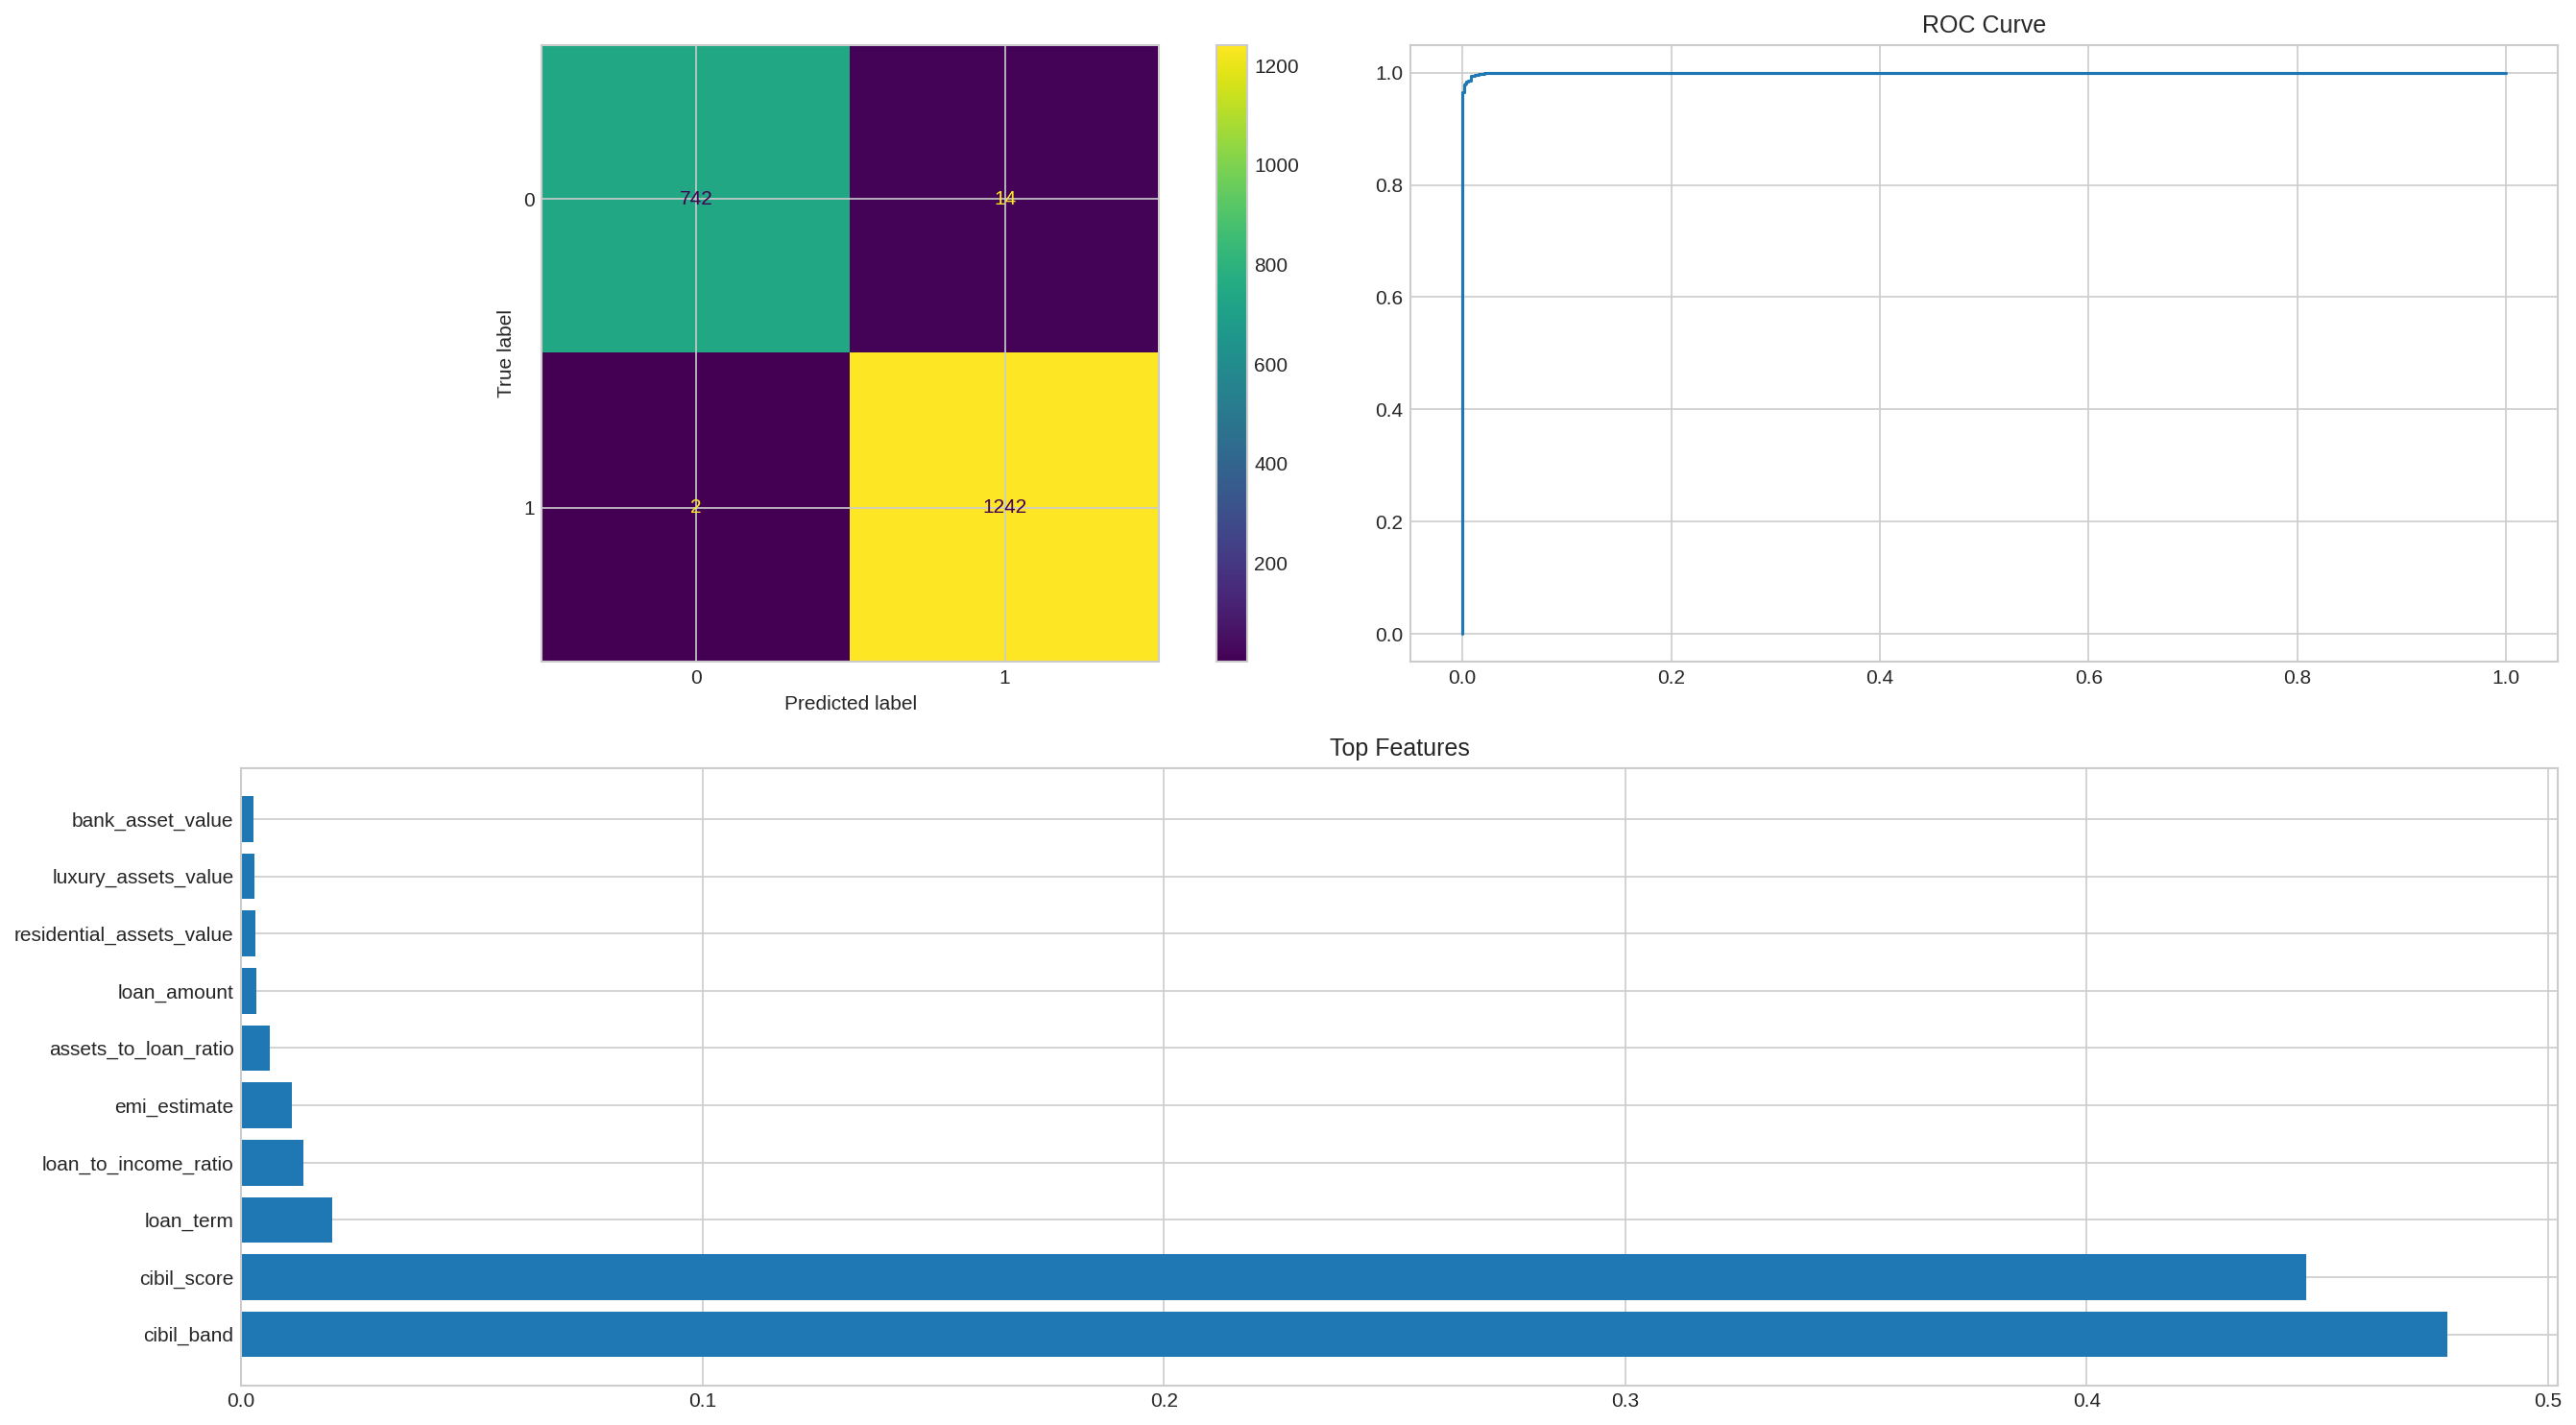


 Image saved at: /content/outputs/loan_rf_model_report.png
Accuracy: 0.9920, F1: 0.9936, ROC-AUC: 0.9998


In [5]:
"""
============================================================
  Loan Approval Prediction — Professional ML Pipeline
  Model : Random Forest Classifier
============================================================
"""

# ── 1. Imports ────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, learning_curve
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# ── 2. Configuration ──────────────────────────────────────
DATA_PATH    = "/content/loan_approval_10000.csv"

#  FIXED PATH FOR COLAB
OUTPUT_DIR   = Path("/content/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.20
CV_FOLDS     = 5

RF_PARAMS = dict(
    n_estimators     = 300,
    max_depth        = 15,
    min_samples_split= 5,
    min_samples_leaf = 2,
    max_features     = "sqrt",
    class_weight     = "balanced",
    random_state     = RANDOM_STATE,
    n_jobs           = -1
)

# ── 3. Load Data ──────────────────────────────────────────
print("=" * 62)
print("   LOAN APPROVAL — RANDOM FOREST CLASSIFIER PIPELINE")
print("=" * 62)

df = pd.read_csv(DATA_PATH)

# ── 4. Preprocessing ──────────────────────────────────────
df.drop(columns=["loan_id"], inplace=True)

le = LabelEncoder()
df["education"]     = le.fit_transform(df["education"])
df["self_employed"] = le.fit_transform(df["self_employed"])

df["loan_status"] = (df["loan_status"].str.strip() == "Approved").astype(int)

if df.isnull().sum().sum() > 0:
    df.fillna(df.median(numeric_only=True), inplace=True)

# ── 5. Feature Engineering ────────────────────────────────
df["loan_to_income_ratio"]  = df["loan_amount"] / (df["income_annum"] + 1)
df["total_assets"]          = (df["residential_assets_value"] +
                              df["commercial_assets_value"] +
                              df["luxury_assets_value"] +
                              df["bank_asset_value"])
df["assets_to_loan_ratio"]  = df["total_assets"] / (df["loan_amount"] + 1)
df["cibil_band"]            = pd.cut(
                                df["cibil_score"],
                                bins=[0, 549, 649, 749, 900],
                                labels=[0, 1, 2, 3]
                              ).astype(int)
df["income_per_dependent"]  = df["income_annum"] / (df["no_of_dependents"] + 1)
df["emi_estimate"]          = df["loan_amount"] / (df["loan_term"] * 12 + 1)

FEATURES = [
    "no_of_dependents", "education", "self_employed",
    "income_annum", "loan_amount", "loan_term", "cibil_score",
    "residential_assets_value", "commercial_assets_value",
    "luxury_assets_value", "bank_asset_value",
    "loan_to_income_ratio", "total_assets", "assets_to_loan_ratio",
    "cibil_band", "income_per_dependent", "emi_estimate"
]

X = df[FEATURES].values
y = df["loan_status"].values

# ── 6. Split ──────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

# ── 7. Model ──────────────────────────────────────────────
model_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(**RF_PARAMS))
])

# ── 8. Train ──────────────────────────────────────────────
model_pipeline.fit(X_train, y_train)

y_pred      = model_pipeline.predict(X_test)
y_pred_prob = model_pipeline.predict_proba(X_test)[:, 1]

# ── 9. Metrics ────────────────────────────────────────────
acc     = accuracy_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# ── 10. Feature Importance ────────────────────────────────
rf_model   = model_pipeline.named_steps["rf"]
importances = rf_model.feature_importances_

feat_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# ── 11. Visualization ─────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2)

# Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(ax=ax1)

# ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax2.plot(fpr, tpr)
ax2.set_title("ROC Curve")

# Feature Importance
ax3 = fig.add_subplot(gs[1, :])
ax3.barh(feat_df["Feature"][:10], feat_df["Importance"][:10])
ax3.set_title("Top Features")

plt.tight_layout()

# ── 12. SAVE + SHOW ───────────────────────────────────────
out_img = OUTPUT_DIR / "loan_rf_model_report.png"

plt.savefig(out_img, dpi=150, bbox_inches="tight")
plt.show()   # SHOW INLINE

#  ALSO DISPLAY SAVED IMAGE
from IPython.display import display
from PIL import Image

display(Image.open(out_img))

print(f"\n Image saved at: {out_img}")
print(f"Accuracy: {acc:.4f}, F1: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")